# 🧠 Introdução às Redes Neurais — Semana 2

Andrew Ng apresenta os conceitos fundamentais para implementar redes neurais, usando **regressão logística** como exemplo para introduzir as ideias principais.

---

## 🔹 1. Processamento de Dados

- Um conjunto de treinamento contém **m exemplos**:  
  $$(x^{(1)}, y^{(1)}), (x^{(2)}, y^{(2)}), …, (x^{(m)}, y^{(m)})$$.
- Em vez de usar *loops* para percorrer cada exemplo, as redes neurais utilizam **vetorização**, processando todos os exemplos simultaneamente.

---

## 🔹 2. Estrutura dos Dados

- Cada imagem é convertida em um **vetor de entrada x**, contendo todos os pixels (RGB).  
  Exemplo: uma imagem 64×64×3 gera um vetor de dimensão **nₓ = 12.288**.
- Todos os vetores de entrada são empilhados em colunas:
  - **X** → matriz de dimensão *(nₓ × m)*  
  - **Y** → matriz de dimensão *(1 × m)*

---

## 🔹 3. Organização da Computação

O aprendizado é dividido em duas etapas principais:

1. **Forward Propagation** — cálculo das previsões da rede.  
2. **Backward Propagation** — cálculo dos gradientes e atualização dos parâmetros.

---

## 🔹 4. Conclusão

A regressão logística serve como **porta de entrada** para compreender:
- A representação matricial dos dados.  
- O fluxo de cálculos dentro de uma rede neural.  
- A base conceitual para redes neurais multicamadas.

---


In [1]:
## Vamos fazer um exemplo no python 

import cv2
import numpy as np
import matplotlib.pyplot as plt

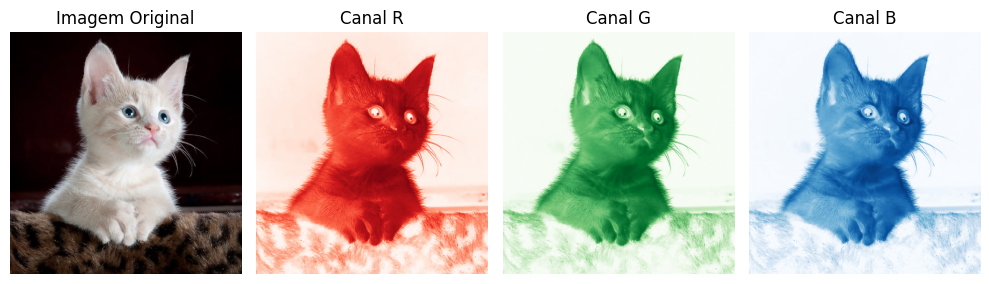

In [2]:
## Leitura da imagem

img = cv2.imread("data_cat_dog/cat2.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

fig, axs = plt.subplots(1, 4, figsize=(10, 4))

axs[0].imshow(img_rgb)
axs[0].set_title("Imagem Original")

axs[1].imshow(R, cmap="Reds")
axs[1].set_title("Canal R")

axs[2].imshow(G, cmap="Greens")
axs[2].set_title("Canal G")

axs[3].imshow(B, cmap="Blues")
axs[3].set_title("Canal B")

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [3]:
img_resized = cv2.resize(img_rgb, (64, 64))
print("Formato da imagem original:", img_rgb.shape)

R = img_resized[:, :, 0]
G = img_resized[:, :, 1]
B = img_resized[:, :, 2]

print("Formato da imagem reshaped:", img_resized.shape)
print("Canal R shape:", R.shape)
print("Canal G shape:", G.shape)
print("Canal B shape:", B.shape)

Formato da imagem original: (523, 500, 3)
Formato da imagem reshaped: (64, 64, 3)
Canal R shape: (64, 64)
Canal G shape: (64, 64)
Canal B shape: (64, 64)


In [4]:
## implementando ideia do Prof.

x = img_resized.flatten().reshape(-1, 1)
# normalizando
x = x/ x.max()
print("Shape do vetor x:", x.shape)  # (12288, 1)

Shape do vetor x: (12288, 1)


In [5]:
## montando um noh da rede

W = np.random.randn(1, x.shape[0]) * 0.01  # (1, 12288)
b = np.zeros((1, 1))  # (1, 1)

print("W shape:", W.shape)
print("b shape:", b.shape)

Z = np.dot(W, x) + b
print("Z:", Z)

W shape: (1, 12288)
b shape: (1, 1)
Z: [[0.00566608]]


## 🧠 Função Sigmoide

A **função sigmoide** é uma função de ativação muito usada em **regressão logística** e em **redes neurais**.  
Ela transforma qualquer número real \( z \) em um valor entre **0 e 1**, podendo ser interpretado como uma **probabilidade**.

### 📘 Definição Matemática

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

### 🧩 Propriedades

- **Intervalo:** \( (0, 1) \)  
- **Forma:** curva em "S" suave  
- **σ(0) = 0.5**  
- **Usos:** modelagem de probabilidade, função de ativação em redes neurais  

### 📊 Interpretação

| Valor de \( z \) | σ(z) aproximado | Interpretação |
|------------------|------------------|----------------|
| -∞               | 0                | Classe 0 (negativa) |
| 0                | 0.5              | Incerteza máxima |
| +∞               | 1                | Classe 1 (positiva) |

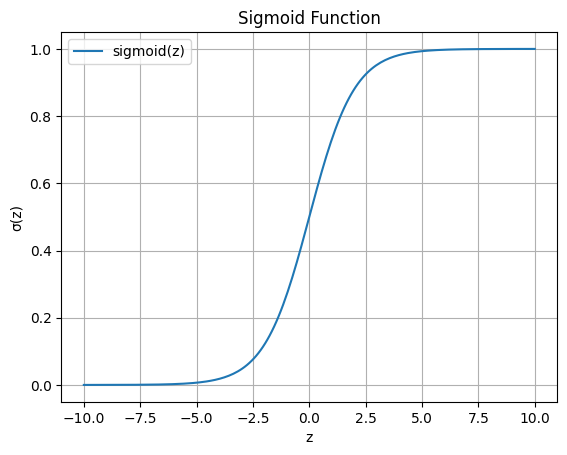

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 200)
s = sigmoid(z)

plt.plot(z, s, label='sigmoid(z)')
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.grid(True)
plt.legend()
plt.show()

In [7]:
## aplica a sigmoide na rede 

Y_hat = sigmoid(np.dot(W, x) + b)
print("Y:", Y_hat)

Y: [[0.50141652]]


## 📘 Função de Custo na Regressão Logística

A **Regressão Logística** busca aprender os parâmetros $ W $ e $ b $ que melhor ajustam os dados, prevendo $ \hat{y} $ o mais próximo possível do rótulo verdadeiro $ y $.

---

### 🔹 Hipótese

A predição é dada pela **função sigmoide**:

$$
\hat{y} = \sigma(W^T x + b)
$$
onde
$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

---

### 🔹 Problema com o Erro Quadrático

Usar o **erro quadrático** como em regressão linear:

$$
L = \frac{1}{2}(\hat{y} - y)^2
$$

não é ideal, pois torna o problema **não convexo**, dificultando a otimização (existem vários mínimos locais).

---

### 🔹 Função de Perda (Loss Function)

Para evitar isso, usamos a **função log-loss** (ou **cross-entropy loss**):

$$
L(\hat{y}, y) = - \big[ y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \big]
$$

#### 🧩 Intuição

- Se $ y = 1 $:  
  $$
  L = -\log(\hat{y}) \Rightarrow \text{queremos } \hat{y} \to 1
  $$

- Se $ y = 0 $:  
  $$
  L = -\log(1 - \hat{y}) \Rightarrow \text{queremos } \hat{y} \to 0
  $$

Ou seja:
- penaliza fortemente previsões erradas com alta confiança;
- é suave e diferenciável → ideal para otimização com **gradiente descendente**.

---

### 🔹 Função de Custo (Cost Function)

A **função de custo total** mede o desempenho médio em todo o conjunto de treino:

$$
J(W, b) = - \frac{1}{m} \sum_{i=1}^{m} \Big[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \Big]
$$

onde:
- $ m $: número de exemplos de treino  
- $ \hat{y}^{(i)} = \sigma(W^T x^{(i)} + b) $

---

### 🎯 Objetivo

Encontrar $ W $ e $ b $ que **minimizem** $ J(W, b) $:

$$
\min_{W, b} \; J(W, b)
$$

---

### 🧠 Conexão com Redes Neurais

A regressão logística pode ser vista como uma **rede neural de um único neurônio**:
- Entrada: vetor $ x $
- Saída: $\hat{y}$
- Função de ativação: sigmoide
- Função de custo: log-loss



In [8]:
## é um gato

Y = np.array([[1]])

In [9]:
# Função de custo (log-loss)

def compute_cost(X, y, w, b):

    m = X.shape[1]  # número de exemplos
    z = np.dot(w.T, X) + b
    y_hat = sigmoid(z)

    # evita log(0)
    eps = 1e-8
    cost = - (1/m) * np.sum(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
    
    return cost

In [10]:
print(compute_cost(x, Y, W.T, b))

0.6903181353094758


# 🧠 Gradiente Descendente na Regressão Logística

## Revisão
- A **função de perda (loss)** mede o erro em um único exemplo de treino.  
- A **função de custo (cost)**, $J(W, b)$, mede o erro médio em todos os exemplos do conjunto de treino.  
- Objetivo: **encontrar $W$ e $b$ que minimizem $J(W, b)$**.

---

## Ideia Intuitiva
- $J(W, b)$ pode ser visualizada como uma **superfície convexa** (um "bowl") em função de $W$ e $b$.  
- O **gradiente descendente** procura o ponto de menor custo movendo-se na direção do **declive mais acentuado** (menor $J$).

---

## Atualização dos Parâmetros
O algoritmo ajusta $W$ e $b$ iterativamente:

$$
W := W - \alpha \frac{\partial J(W, b)}{\partial W}
$$

$$
b := b - \alpha \frac{\partial J(W, b)}{\partial b}
$$

onde:
- $\alpha$ é a **taxa de aprendizado (learning rate)**;  
- $\frac{\partial J}{\partial W}$ e $\frac{\partial J}{\partial b}$ representam os **gradientes** (ou derivadas parciais).

---

## Intuição Geométrica
- Se o gradiente for **positivo**, o custo aumenta com $W$ ⇒ damos um passo **para a esquerda** (reduzindo $W$).  
- Se o gradiente for **negativo**, o custo diminui com $W$ ⇒ damos um passo **para a direita** (aumentando $W$).  
- Repetindo isso várias vezes, o algoritmo converge para o **mínimo global**.

---

## Notação
- `dW` → representa $\frac{\partial J}{\partial W}$ no código.  
- `db` → representa $\frac{\partial J}{\partial b}$.  
- A letra **∂** (derivada parcial) é usada quando a função depende de **mais de uma variável** (ex: $W$ e $b$).  

---

## Intuição Final
Mesmo sem dominar cálculo, é importante entender que o **gradiente** indica a **direção de maior crescimento** da função de custo —  
e o **gradiente descendente** simplesmente caminha no sentido oposto, **reduzindo o erro** a cada iteração.


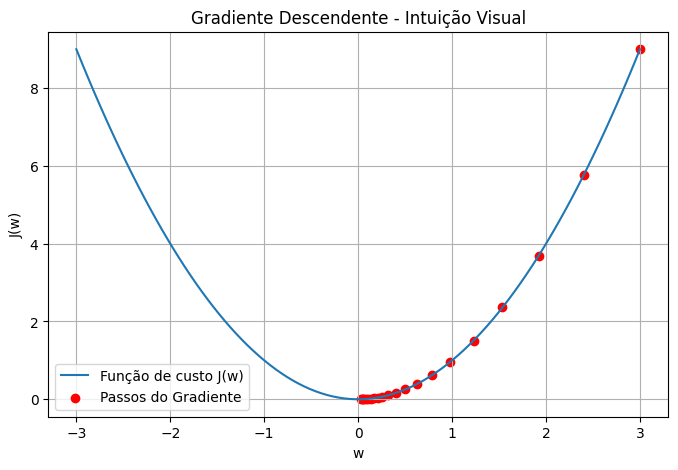

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Função de custo (exemplo simples - parabólica)
def J(w):
    return w**2

# Derivada (gradiente)
def dJ(w):
    return 2*w

# Parâmetros iniciais
w = 3.0              # ponto inicial
alpha = 0.1          # taxa de aprendizado
iterations = 20

# Armazena o histórico
ws = [w]
costs = [J(w)]

# Loop de gradiente descendente
for i in range(iterations):
    grad = dJ(w)
    w = w - alpha * grad
    ws.append(w)
    costs.append(J(w))

# Plot da função de custo
w_vals = np.linspace(-3, 3, 100)
plt.figure(figsize=(8,5))
plt.plot(w_vals, J(w_vals), label="Função de custo J(w)")
plt.scatter(ws, costs, color="red", label="Passos do Gradiente")
plt.title("Gradiente Descendente - Intuição Visual")
plt.xlabel("w")
plt.ylabel("J(w)")
plt.legend()
plt.grid(True)
plt.show()


In [12]:
# Função de custo e gradiente
def compute_cost_and_gradients(X, Y, W, b):
    m = X.shape[1]  # número de exemplos
    Z = np.dot(W, X) + b
    A = sigmoid(Z)

    # Custo (log-loss)
    epsilon = 1e-15
    cost = -(1/m) * np.sum(Y * np.log(A + epsilon) + (1 - Y) * np.log(1 - A + epsilon))
    print("Custo", cost)
    
    # Gradientes
    dW = (1/m) * np.dot(X, (A - Y).T)
    db = (1/m) * np.sum(A - Y)

    return cost, dW, db

In [13]:
cost, dW, db = compute_cost_and_gradients(x, Y, W, b)

Custo 0.6903181552529732


In [14]:
W.shape, b.shape, 

((1, 12288), (1, 1))

In [15]:
def update_parameters(alpha, W, dW, b, db):

    W = W - alpha * dW.T
    b = b - alpha * db.T
    return W, b

In [16]:
alpha = 0.01

W2, b2 = update_parameters(alpha, W, dW, b, db)

In [17]:
W2.shape, b2.shape

((1, 12288), (1, 1))

## Montando o Algoritmo 

In [18]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost_and_gradients(X, Y, W, b):
    m = X.shape[1]
    Z = np.dot(W, X) + b
    A = sigmoid(Z)
    
    epsilon = 1e-15
    cost = -(1/m) * np.sum(Y * np.log(A + epsilon) + (1 - Y) * np.log(1 - A + epsilon))
    
    dW = (1/m) * np.dot((A - Y), X.T)
    db = (1/m) * np.sum(A - Y)
    
    return cost, dW, db

def update_parameters(alpha, W, dW, b, db):
    W = W - alpha * dW
    b = b - alpha * db
    return W, b

In [19]:
# === Dados ===

img = cv2.imread("data_cat_dog/cat2.jpeg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img_rgb, (64, 64))

X = img_resized.flatten().reshape(-1, 1) / 255.0  
Y = np.array([[1]])

W = np.random.randn(1, X.shape[0]) * 0.01
b = np.zeros((1, 1))

alpha = 0.001

# === Treino ===
for i in range(10):
    cost, dW, db = compute_cost_and_gradients(X, Y, W, b)
    W, b = update_parameters(alpha, W, dW, b, db)
    print(f"Epoch {i} | Custo: {cost:.6f}")

Epoch 0 | Custo: 0.422822
Epoch 1 | Custo: 0.224405
Epoch 2 | Custo: 0.151529
Epoch 3 | Custo: 0.114301
Epoch 4 | Custo: 0.091754
Epoch 5 | Custo: 0.076640
Epoch 6 | Custo: 0.065804
Epoch 7 | Custo: 0.057655
Epoch 8 | Custo: 0.051304
Epoch 9 | Custo: 0.046214


## Algoritmo para cachorro e gato

In [20]:
# === Função auxiliar para carregar imagem ===
def load_image(path):
    img = cv2.imread(path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (64, 64))
    return img_resized.flatten().reshape(-1, 1) / 255.0  # normalizado

# === Dados ===
x_cat = load_image("data_cat_dog/cat1.jpg")
x_cat2 = load_image("data_cat_dog/cat2.jpeg")

x_dog = load_image("data_cat_dog/dog1.jpeg")
x_dog2 = load_image("data_cat_dog/dog2.jpeg")

# Junta os dois exemplos: cada coluna é uma imagem
X = np.concatenate((x_cat, x_cat2, x_dog, x_dog2), axis=1) 
Y = np.array([[1, 1, 0, 0]])                     # gato=1, cachorro=0

In [21]:
# Inicializa parâmetros
W = np.random.randn(1, X.shape[0]) * 0.001
b = np.zeros((1, 1))
alpha = 0.01

# === Treino ===
for i in range(100):
    cost, dW, db = compute_cost_and_gradients(X, Y, W, b)
    W, b = update_parameters(alpha, W, dW, b, db)
    if i % 10 == 0:
        print(f"\nEpoch {i} | Custo: {cost:.6f}")

        # === Predição ===
        Z = np.dot(W, X) + b
        A = sigmoid(Z)
        preds = (A > 0.5).astype(int)
        
        print("Predições:", preds)
        print("Labels reais:", Y)


Epoch 0 | Custo: 0.701415
Predições: [[0 1 0 0]]
Labels reais: [[1 1 0 0]]

Epoch 10 | Custo: 0.011250
Predições: [[1 1 0 0]]
Labels reais: [[1 1 0 0]]

Epoch 20 | Custo: 0.007785
Predições: [[1 1 0 0]]
Labels reais: [[1 1 0 0]]

Epoch 30 | Custo: 0.006825
Predições: [[1 1 0 0]]
Labels reais: [[1 1 0 0]]

Epoch 40 | Custo: 0.006099
Predições: [[1 1 0 0]]
Labels reais: [[1 1 0 0]]

Epoch 50 | Custo: 0.005522
Predições: [[1 1 0 0]]
Labels reais: [[1 1 0 0]]

Epoch 60 | Custo: 0.005049
Predições: [[1 1 0 0]]
Labels reais: [[1 1 0 0]]

Epoch 70 | Custo: 0.004653
Predições: [[1 1 0 0]]
Labels reais: [[1 1 0 0]]

Epoch 80 | Custo: 0.004316
Predições: [[1 1 0 0]]
Labels reais: [[1 1 0 0]]

Epoch 90 | Custo: 0.004026
Predições: [[1 1 0 0]]
Labels reais: [[1 1 0 0]]
